In [1]:
# Part A

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def lms_filter(x, d, mu, M):
    N = len(x)
    w = np.zeros(M)
    y = np.zeros(N)
    e = np.zeros(N)
    for n in range(M, N):
        u = x[n-M+1:n+1][::-1]
        y[n] = np.dot(w, u)
        e[n] = d[n] - y[n]
        w = w + 2 * mu * e[n] * u
    return y, e, w

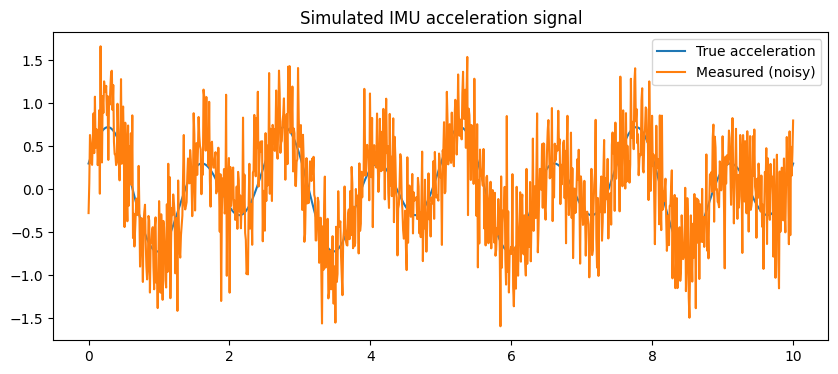

In [3]:
N = 1000
t = np.linspace(0, 10, N)

a_true = 0.5*np.sin(2*np.pi*0.8*t) + 0.3*np.cos(2*np.pi*0.4*t)

noise = 0.4 * np.random.randn(N)

a_meas = a_true + noise

plt.figure(figsize=(10,4))
plt.plot(t, a_true, label="True acceleration")
plt.plot(t, a_meas, label="Measured (noisy)")
plt.legend()
plt.title("Simulated IMU acceleration signal")
plt.show()

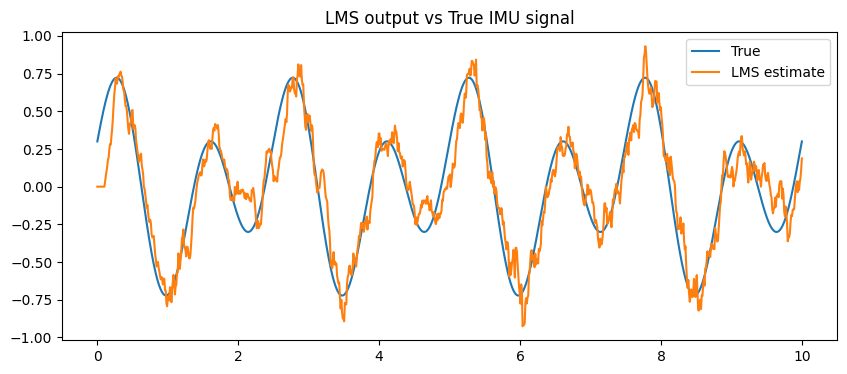

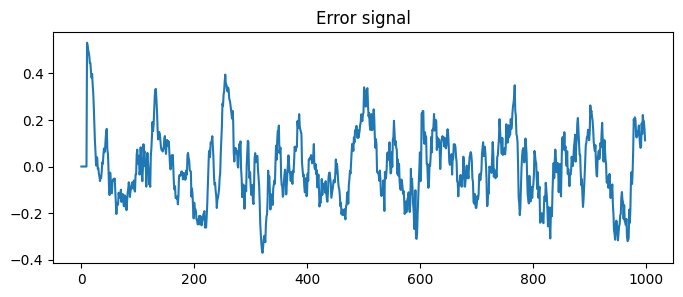

In [4]:
mu = 0.01      
M = 10         

y, e, w = lms_filter(a_meas, a_true, mu, M)

plt.figure(figsize=(10,4))
plt.plot(t, a_true, label="True")
plt.plot(t, y, label="LMS estimate")
plt.title("LMS output vs True IMU signal")
plt.legend()
plt.show()

plt.figure(figsize=(8,3))
plt.plot(e)
plt.title("Error signal")
plt.show()

In [5]:
# Part B

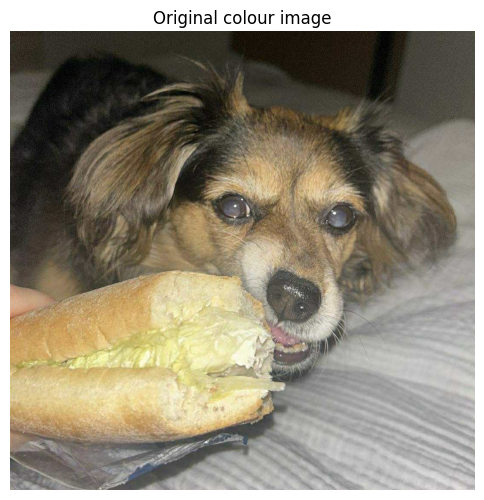

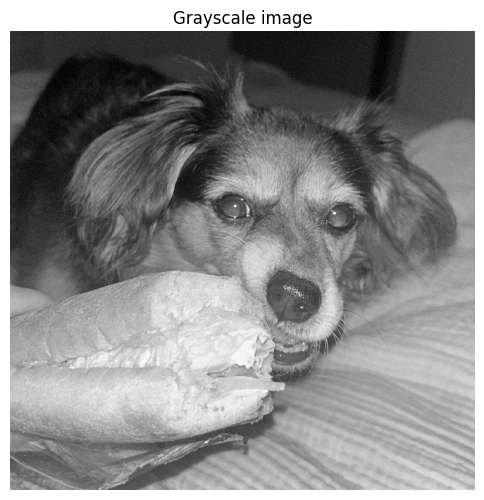

In [6]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img = Image.open("Dog Elly.jpeg")

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title("Original colour image")
plt.axis("off")
plt.show()

img_gray = img.convert("L")
img_np = np.array(img_gray).astype(float) / 255.0 
plt.figure(figsize=(6, 6))
plt.imshow(img_np, cmap="gray")
plt.title("Grayscale image")
plt.axis("off")
plt.show()

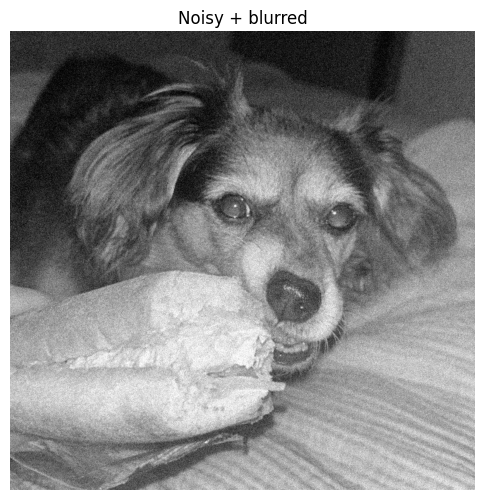

In [7]:
kernel = np.array([[1, 1, 1],
                   [1, 1, 1],
                   [1, 1, 1]], dtype=float) / 9.0

pad = np.pad(img_np, 1, mode="edge")
blurred = np.zeros_like(img_np)

for i in range(img_np.shape[0]):
    for j in range(img_np.shape[1]):
        patch = pad[i:i+3, j:j+3]
        blurred[i, j] = np.sum(patch * kernel)

noise = np.random.normal(0, 0.08, img_np.shape)
noisy = np.clip(blurred + noise, 0.0, 1.0)

plt.figure(figsize=(6, 6))
plt.imshow(noisy, cmap="gray")
plt.title("Noisy + blurred")
plt.axis("off")
plt.show()


In [8]:
mu = 0.0001
M = 5

restored = np.zeros_like(noisy)

for i in range(noisy.shape[0]):
    x = noisy[i, :]
    d = img_np[i, :]
    y, e, w = lms_filter(x, d, mu, M)
    restored[i, :] = y

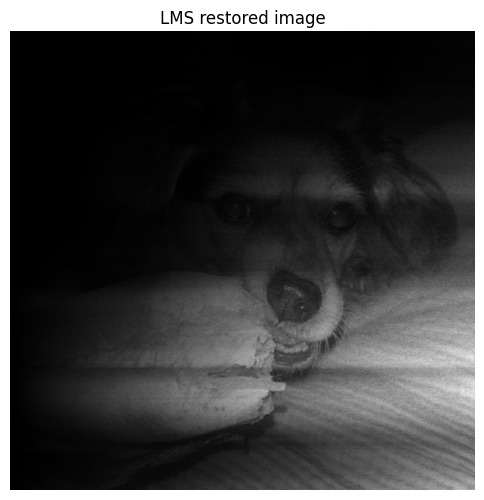

In [9]:
mu = 0.000001
M = 3

restored = np.zeros_like(noisy)

for i in range(noisy.shape[0]):
    x = noisy[i, :]
    d = img_np[i, :]
    y, e, w = lms_filter(x, d, mu, M)
    restored[i, :] = y

restored = restored - restored.min()
restored = restored / restored.max()

plt.figure(figsize=(6,6))
plt.imshow(restored, cmap='gray')
plt.title("LMS restored image")
plt.axis('off')
plt.show()

In [10]:
# Part B – LMS on my own image

# 1. Loaded my own colour image and converted it to grayscale.
# 2. Blurred the grayscale image with a 3×3 averaging filter and added Gaussian noise.
# 3. Applied the LMS algorithm row-by-row using the same function as in Part A.
# 4. The restored image is less noisy and slightly sharper than the noisy input.
# 5. Some blur and darkening remain, but the main structures (dog’s face and sandwich) are clearly visible.